# Głębokie Uczenie w Praktyce
## Laboratorium 1
### Mateusz Horczak


#### Ćwiczenie 1 Ładowanie zbioru danych MNIST
- Załaduj zbiór danych MNIST, wyświetl ich kształt, ilość, typ itp.

In [464]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

from tensorflow import keras

from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

In [465]:
# define constants numbers
train_size = 60000
test_size = 10000
numbers = 10
image_width = 28
image_height = 28
image_size = image_width * image_height
max_pixel_value = 255

In [466]:
# Load mist data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

In [467]:
print('train images shape:')
display(train_images.shape)

print('\ntrain labels length:')
display(len(train_labels))

print('\ntrain labels:')
display(train_labels)

train images shape:


(60000, 28, 28)


train labels length:


60000


train labels:


array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [468]:
print('train images dtype:')
display(train_images.dtype)

train images dtype:


dtype('uint8')

In [469]:
print('train images [0]:')
train_images[0]

train images [0]:


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [470]:
print('test images shape:')
display(test_images.shape)

print('\ntest labels length:')
display(len(test_labels))

print('\ntest labels:')
display(test_labels)

test images shape:


(10000, 28, 28)


test labels length:


10000


test labels:


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

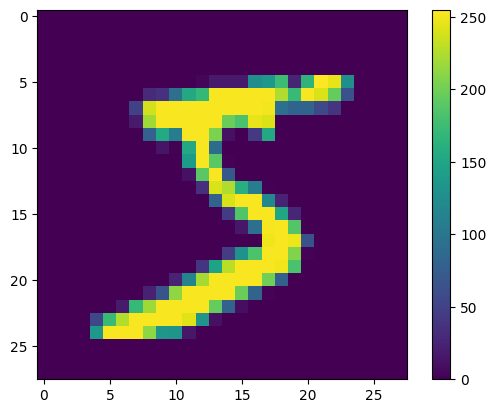

In [471]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

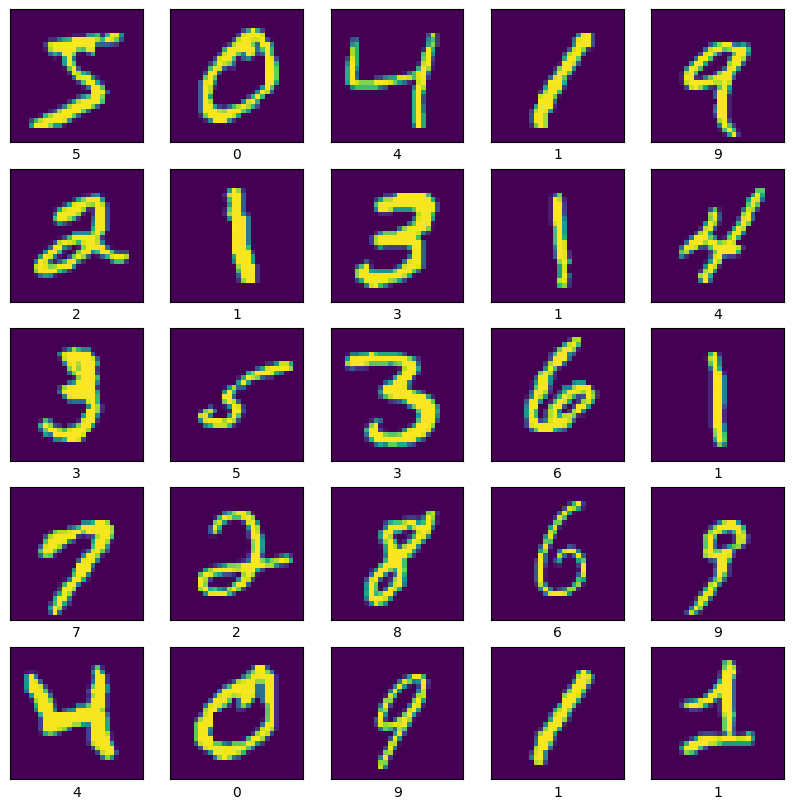

In [472]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(train_labels[i])
plt.show()

#### Ćwiczenie 2 Przygotowanie danych

In [473]:
train_images = train_images.reshape((train_size, image_size))
train_images = train_images.astype('float32') / max_pixel_value
test_images = test_images.reshape((test_size, image_size))
test_images = test_images.astype('float32') / max_pixel_value
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [474]:
print('train images shape:')
display(train_images.shape)

print('\ntrain labels length:')
display(len(train_labels))

train images shape:


(60000, 784)


train labels length:


60000

In [475]:
print('\ntrain labels:')
train_labels


train labels:


array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

Na czym polegała transformacja?
- Na spłaszczeniu obrazu 28x28px do wektora o długości 784
- Na zmianie typu danych z uint8 na float32
- Podzielenie przez 255 normalizuje dane

#### Ćwiczenie 3 Utwórz warstwy sieci
- Utwórz warstwy sieci i ustaw opcje funkcji straty i optimizatora.

In [476]:
neurons = 512

network = models.Sequential()
network.add(layers.Input(shape=(image_size,)))
network.add(layers.Dense(neurons, activation='relu'))
network.add(layers.Dense(numbers, activation='softmax'))
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
network.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Przelicz skąd się wzięły liczby parametrów sieci
- wzór: liczba wejść * liczba neuronów w warstwie + bias
- (28 * 28) * 512 + 512 = 401 920
- 512 * 10 + 10 = 5 130 (512 jako wyjście z poprzedniej warstwy)
- łącznie: 401 920 + 5 130 = 407 050


#### Ćwiczenie 4. Trenowanie sieci

In [477]:
network.fit(train_images, train_labels, epochs=7, batch_size=128)

Epoch 1/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9235 - loss: 0.2622
Epoch 2/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9685 - loss: 0.1071
Epoch 3/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9785 - loss: 0.0704
Epoch 4/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9848 - loss: 0.0516
Epoch 5/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0388
Epoch 6/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9914 - loss: 0.0291
Epoch 7/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9939 - loss: 0.0221


#### Ćwiczenie 5. Ewaluacja

In [478]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

print('Test accuracy:')
display(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9810 - loss: 0.0628
Test accuracy:


0.9810000061988831

#### Ćwiczenie 6. Predykcja przykładów

In [479]:
predictions = network.predict(test_images)
print('prediction table:')
print(predictions[0])

print('\nprediction value:', np.argmax(predictions[0]))
print('\ncorrect value:', test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
prediction table:
[2.92059221e-09 5.91989582e-11 2.70791304e-07 3.83502520e-05
 5.57100969e-13 2.37306761e-08 8.47485385e-13 9.99960244e-01
 1.42565515e-08 1.07425330e-06]

prediction value: 7

correct value: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


#### Ćwiczenie 7. Detekcja narysowanej cyfry
- Narysuj cyfrę w jakimś programie graficznym. (np. Paint)
- Wczytaj ją do numpy array (28, 28)
- Użyj sieci nauczonej sieci do detekcji cyfry.
- Przetestuj na wszystkich rodzajach cyfr

In [480]:
def predict_drawn_digit(file_path, network):
    # convert to grayscale
    img = Image.open(file_path).convert('L')

    # scale to 28x28
    img = img.resize((image_width, image_height))

    # normalize
    img_array = np.array(img).astype('float32') / max_pixel_value

    # invert color
    img_array = 1 - img_array

    img_flat = img_array.reshape(1, image_width * image_height)

    prediction = network.predict(img_flat)
    predicted_digit = np.argmax(prediction)
    probabilities = prediction[0]

    return predicted_digit, probabilities

for i in range(numbers):
    file_path = f"lab1/numbers/{i}.png"
    if os.path.exists(file_path):
        predicted, probs = predict_drawn_digit(file_path, network)
        confidence = probs[predicted] * 100
        print(f"File: {file_path} (drawn number {i})")
        print(f"Predicted number: {predicted} (confidence: {confidence:.2f}%)")
        print("-----")
    else:
        print(f"File {file_path} not found. Draw and save {i} as {file_path}.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
File: lab1/numbers/0.png (drawn number 0)
Predicted number: 0 (confidence: 92.56%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
File: lab1/numbers/1.png (drawn number 1)
Predicted number: 1 (confidence: 90.20%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
File: lab1/numbers/2.png (drawn number 2)
Predicted number: 2 (confidence: 99.19%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
File: lab1/numbers/3.png (drawn number 3)
Predicted number: 3 (confidence: 100.00%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
File: lab1/numbers/4.png (drawn number 4)
Predicted number: 4 (confidence: 99.98%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
File: lab1/numbers/5.png (drawn number 5)
Predicted number: 5 (confidence: 99.99%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
File: lab1/numbers/6.png (drawn number 6)
Predicted number: 6 (confidence: 91.35%)
-----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
File: lab1/numbers/7.png (drawn number 7)
Predicted number: 7 (confidenc